# Task 1 EDA — Understanding Credit Risk

This notebook runs the required EDA steps by calling reusable functions from `eda.py`, so the notebook itself only holds configuration, function calls, and the business commentary — no repeated plotting code.

In [6]:
from pathlib import Path
import sys

# eda.py lives alongside data_processing.py (adjust if your layout differs)
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

import eda

DATA_PATH = project_root / 'data' / 'data.csv'
TARGET_COL = 'FraudResult'
NUMERIC_COLS = ['Amount', 'Value', 'PricingStrategy']
CATEGORICAL_COLS = ['ProductCategory', 'ChannelId', 'ProviderId']
LOG_SCALE_COLS = ['Amount', 'Value']

df = eda.load_data(DATA_PATH)

## 1. Overview of the Data
Understand the structure of the dataset, including the number of rows, columns, and data types.

In [7]:
eda.overview(df)

Shape: 95,662 rows x 16 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  object             
 1   BatchId               95662 non-null  object             
 2   AccountId             95662 non-null  object             
 3   SubscriptionId        95662 non-null  object             
 4   CustomerId            95662 non-null  object             
 5   CurrencyCode          95662 non-null  object             
 6   CountryCode           95662 non-null  object             
 7   ProviderId            95662 non-null  object             
 8   ProductId             95662 non-null  object             
 9   ProductCategory       95662 non-null  object             
 10  ChannelId             95662 non-null  object             
 11  Amount                95662 non-nu

## 2. Summary Statistics
Understand the central tendency, dispersion, and shape of the dataset's distribution.

In [8]:
eda.summary_statistics(df, NUMERIC_COLS)

,count,mean,std,min,25%,50%,75%,max
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0


In [9]:
eda.skew_kurtosis_table(df, NUMERIC_COLS)

,Skewness,Kurtosis
Amount,51.10,3363.13
Value,51.29,3378.07
PricingStrategy,1.66,2.09


## 3. Distribution of Numerical Features
Visualize the distribution of numerical features to identify patterns, skewness, and potential outliers.

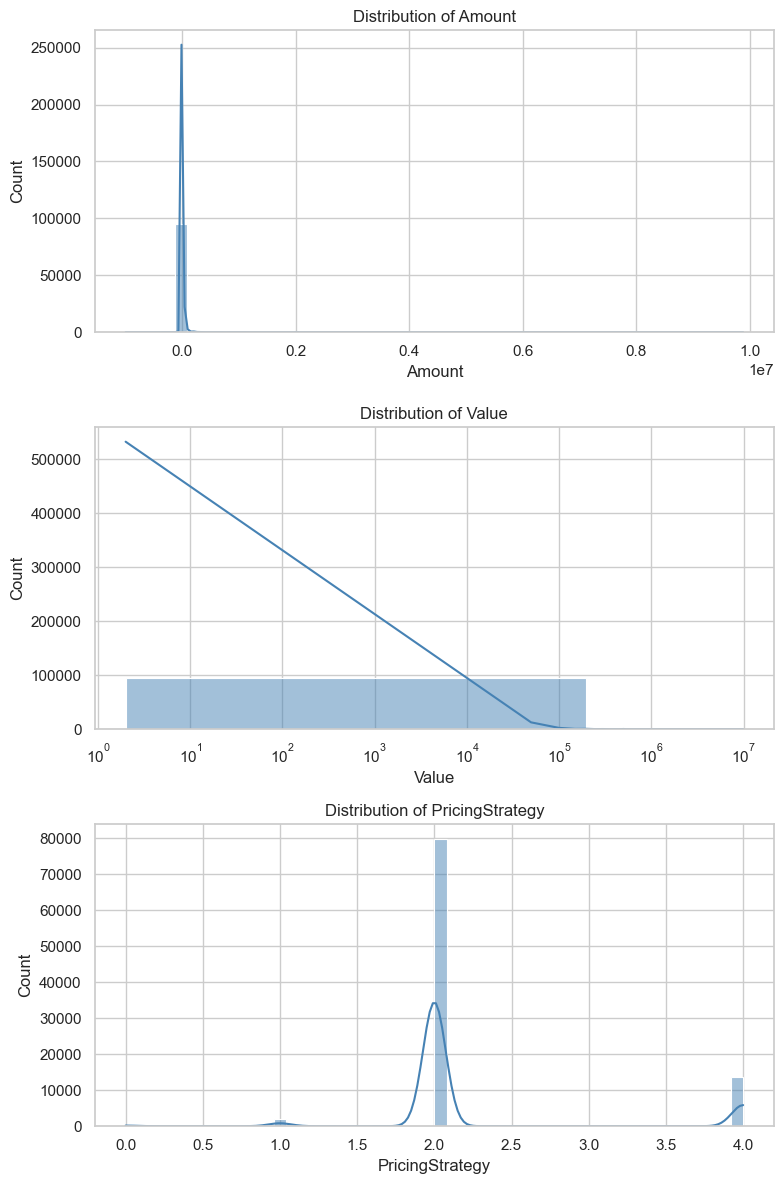

In [10]:
eda.plot_numerical_distributions(df, NUMERIC_COLS, log_scale_cols=LOG_SCALE_COLS)

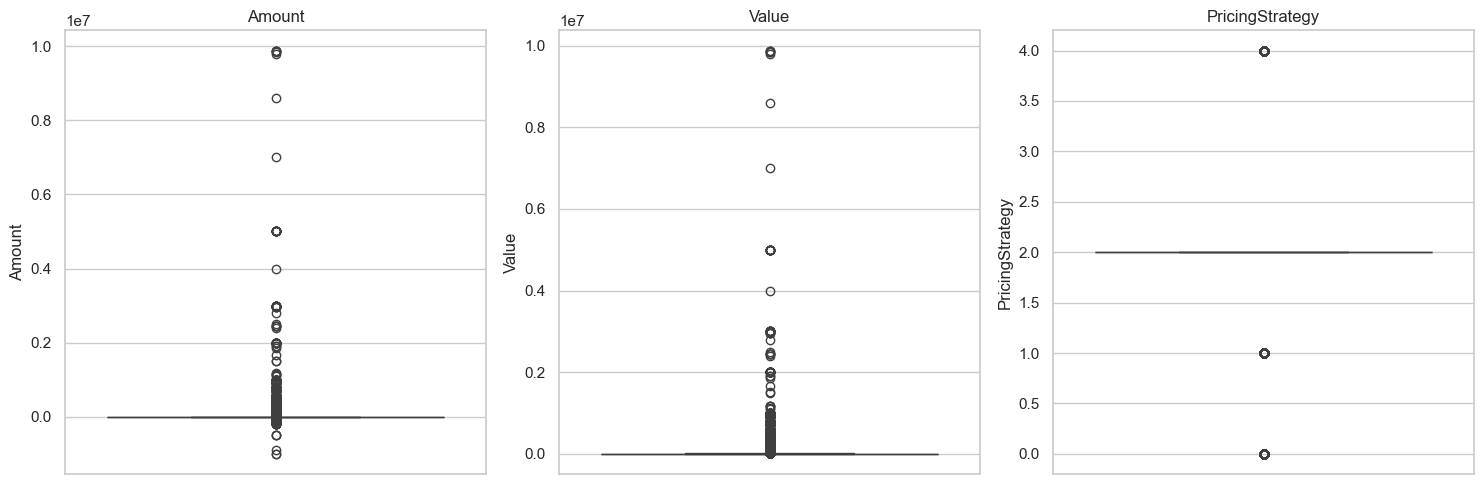

In [11]:
eda.plot_outlier_boxplots(df, NUMERIC_COLS)

In [12]:
eda.iqr_outlier_summary(df, NUMERIC_COLS)

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
0,Amount,-4325.0,7075.0,24441,25.55
2,PricingStrategy,2.0,2.0,15814,16.53
1,Value,-6812.5,12087.5,9021,9.43


The log-scaled histogram for `Value` reveals a highly multimodal distribution. Rather than a smooth curve, transaction values cluster into distinct peaks or "tiers" (e.g. spikes around the 50, 1,000, and 10,000 marks), suggesting distinct pricing tiers or standard top-up amounts.

**Outliers:** the boxplots confirm massive outliers extending well beyond typical ranges. These cannot be removed entirely, since they may carry genuine fraud signal, but they will require robust scaling (e.g. `RobustScaler` or capping via the `OutlierCapper` step already in the pipeline) rather than being dropped.

### Target balance check

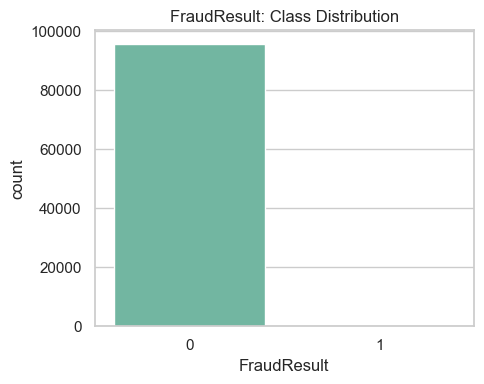

FraudResult
0    0.997982
1    0.002018
Name: proportion, dtype: float64

In [13]:
eda.plot_target_distribution(df, TARGET_COL)

Only a small fraction of transactions are flagged fraudulent, so **accuracy cannot be used as an evaluation metric**. The model must be evaluated with Precision, Recall, F1-Score, and ROC-AUC, and training should account for the class imbalance (e.g. SMOTE, down-sampling, or class-weight adjustments).

## 4. Distribution of Categorical Features
Analyzing the distribution of categorical features provides insight into the frequency and variability of categories.

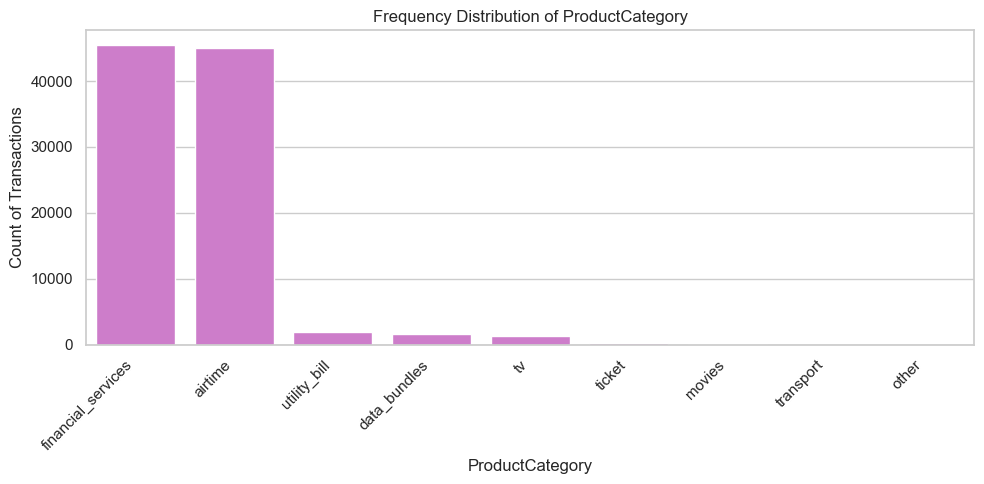

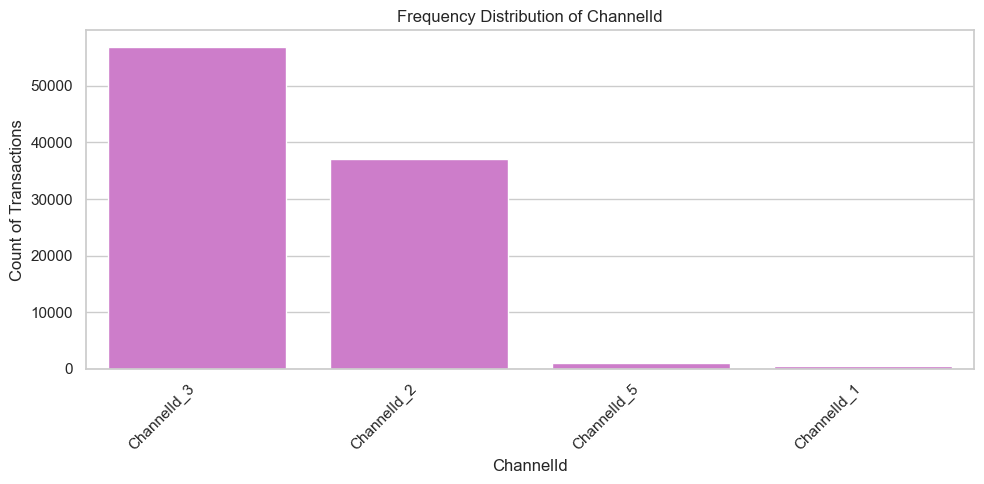

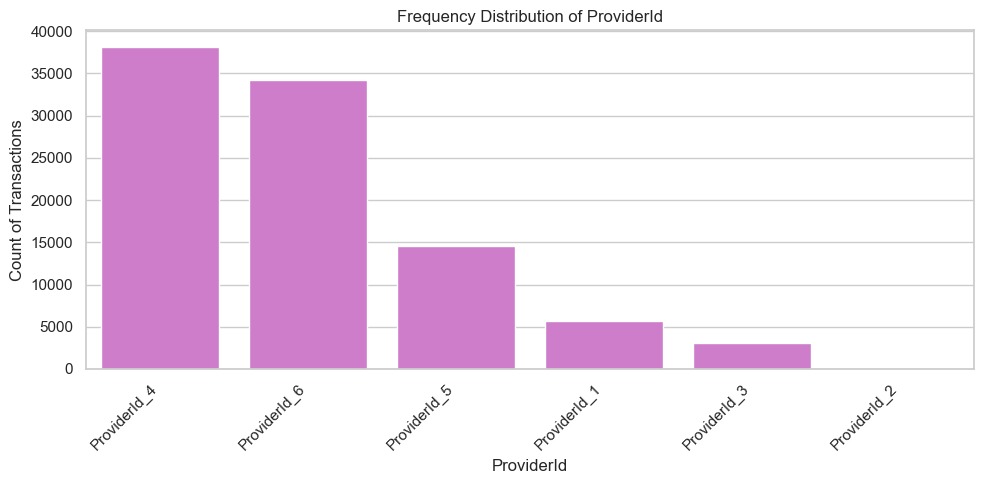

In [14]:
eda.plot_categorical_distributions(df, CATEGORICAL_COLS)

**Product Category:** volume is dominated by `financial_services` and `airtime`, which together account for the large majority of transactions; lifestyle categories such as movies, ticket, and transport are a negligible share.

## 5. Correlation Analysis
Understanding the relationship between numerical features. Spearman (rank) correlation is used since the features are heavy-tailed and the target is a rare binary event.

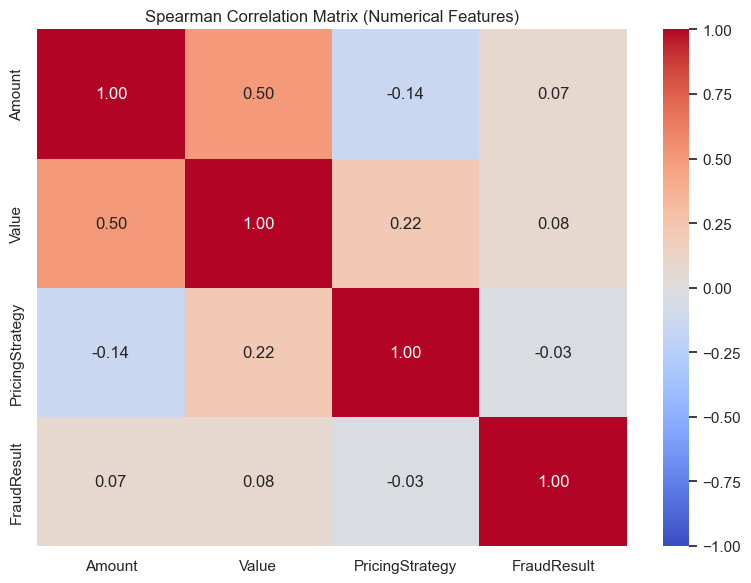

,Amount,Value,PricingStrategy,FraudResult
Amount,1.000000,0.497395,-0.140729,0.073457
Value,0.497395,1.000000,0.217440,0.077040
PricingStrategy,-0.140729,0.217440,1.000000,-0.031079
FraudResult,0.073457,0.077040,-0.031079,1.000000


In [15]:
eda.correlation_heatmap(df, NUMERIC_COLS + [TARGET_COL], method='spearman')

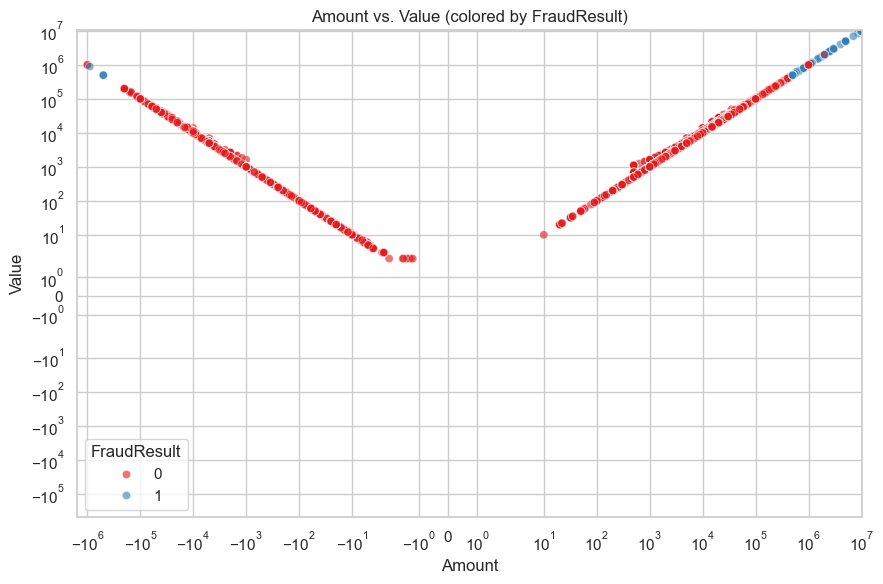

In [16]:
eda.scatter_by_target(df, 'Amount', 'Value', TARGET_COL)

`FraudResult` correlates weakly with the raw `Amount`/`Value` fields. This confirms fraud/default risk is **not** simply a function of transaction size — the relationship is non-linear, which justifies engineering behavioral features (RFM aggregates, Weight of Evidence encodings) rather than relying on raw transaction amounts.

## 6. Identifying Missing Values
Identify missing values to decide on appropriate imputation strategies.

In [17]:
eda.missing_value_report(df)

,missing_count,missing_pct
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


The dataset shows 100% completeness with no missing values in the historical batch. To keep the production pipeline robust against future data drift, the imputation strategy is still defined proactively:

- **Numeric features** (`Amount`, `Value`): median imputation, so future gaps don't skew the heavy-tailed distribution.
- **Categorical features**: impute with the constant `'Missing'`, so the model can learn if absence of data is itself a risk signal.